In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('healthcare_dataset.csv')

Step 1 first look Always do this


In [3]:
print("Total no of rows and cols:",df.shape)
print("first 5 rows of the dataset:",df.head(5))
print("    /       ")
print("data-types+null counts:",df.info())

Total no of rows and cols: (55500, 15)
first 5 rows of the dataset:             Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number

In [4]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


Dtypes is a series object means when u call it pandas crreates a series where index are col names and values are data types


df.dtypes[col] → looks up the dtype from the Series of dtypes.

df[col].dtype → asks the actual column (Series) for its dtype. dono same kaam krte

In [5]:
for col in df.columns:
    print(f" Data types of each column: {col}= {df.dtypes[col]}")

 Data types of each column: Name= object
 Data types of each column: Age= int64
 Data types of each column: Gender= object
 Data types of each column: Blood Type= object
 Data types of each column: Medical Condition= object
 Data types of each column: Date of Admission= object
 Data types of each column: Doctor= object
 Data types of each column: Hospital= object
 Data types of each column: Insurance Provider= object
 Data types of each column: Billing Amount= float64
 Data types of each column: Room Number= int64
 Data types of each column: Admission Type= object
 Data types of each column: Discharge Date= object
 Data types of each column: Medication= object
 Data types of each column: Test Results= object


In [6]:
#change data type of date of admission to int 
df["Date of Admission"]= pd.to_datetime(df["Date of Admission"], errors='coerce')

print(df["Date of Admission"].dtype)



datetime64[ns]


Step 2 check for null values

In [ ]:
print(f"hello: {df.isnull().sum()}") #print null count per column
print(df.isnull().sum()/len(df)*100)

helloName                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
length of stay        0
dtype: int64
Name                  0.0
Age                   0.0
Gender                0.0
Blood Type            0.0
Medical Condition     0.0
Date of Admission     0.0
Doctor                0.0
Hospital              0.0
Insurance Provider    0.0
Billing Amount        0.0
Room Number           0.0
Admission Type        0.0
Discharge Date        0.0
Medication            0.0
Test Results          0.0
length of stay        0.0
dtype: float64


Rules of Thumb 
less than 5% missing - drop 
5%-30% fill with mean/median/mode
more than 30%- dimaag lagao

STEP 3 fix data types

coerce - persuading to do something by direct force

In [ ]:
# we have already changed dat type of Date of admission we will do now for discharge date

df["Discharge Date"]= pd.to_datetime(df["Discharge Date"], errors='coerce')

New col length of stay


In [9]:
df["length of stay"]= (df["Discharge Date"]-df["Date of Admission"]).dt.days


In [10]:
for col in df.columns:
    print(f"{df['Name']} and their stay length: {col} = {df['length of stay']}")

0            Bobby JacksOn
1             LesLie TErRy
2              DaNnY sMitH
3             andrEw waTtS
4            adrIENNE bEll
               ...        
55495    eLIZABeTH jaCkSOn
55496           KYle pEREz
55497         HEATher WaNG
55498       JENniFER JOneS
55499         jAMES GARCiA
Name: Name, Length: 55500, dtype: object and their stay length: Name = 0         2
1         6
2        15
3        30
4        20
         ..
55495    30
55496     9
55497    28
55498     6
55499    27
Name: length of stay, Length: 55500, dtype: int64
0            Bobby JacksOn
1             LesLie TErRy
2              DaNnY sMitH
3             andrEw waTtS
4            adrIENNE bEll
               ...        
55495    eLIZABeTH jaCkSOn
55496           KYle pEREz
55497         HEATher WaNG
55498       JENniFER JOneS
55499         jAMES GARCiA
Name: Name, Length: 55500, dtype: object and their stay length: Age = 0         2
1         6
2        15
3        30
4        20
         ..
55495    30

Check if billing amount is numeric

In [13]:
df.columns
print(df['Billing Amount'].dtype)

float64


REMOVE DUPLICATES

python me true = 1 or false =0 treat,
duplicated() will return true if the row is repeated and sum will count 

a row is termed as duplicated if and only if all the attributes of one row is equal to all the attributes of another row

to use subset use ->duplicated(subset=[])

In [15]:
df.duplicated()
print(df.duplicated().sum())

534


keep parameter we also use
keep has
first- keeps first occurence
last - keeps last occurence
false - no occurence

inplace
false- new dataframe is made original unchanged
true - original dataframe is modified 

In [16]:
print(df.drop_duplicates())

                    Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
55495  eLIZABeTH jaCkSOn   42  Female         O+            Asthma   
55496         KYle pEREz   61  Female        AB-           Obesity   
55497       HEATher WaNG   38  Female         B+      Hypertension   
55498     JENniFER JOneS   43    Male         O-         Arthritis   
55499       jAMES GARCiA   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith               Sons and Miller   
1        

In [17]:
print(df.drop_duplicates(subset =["Name","Date of Admission"]))

                    Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
49995        JOSepH PaUl   64    Male         O+      Hypertension   
49996     braDleY dAniEL   69    Male         B+            Cancer   
49997       LiSa sIMPsoN   73    Male         O-            Cancer   
49998      RoGER farRELl   81    Male         B-            Cancer   
49999  kaTheRIne WeBSTer   23    Male         B+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith               Sons and Miller   
1        

Fix Text Inconsistencies

Unique()-> is a series method it does work on col/series not full dataframe 
so we can never use liket his df.unique() we need to specify colum like df[].unqiue()

In [18]:
# Check unique values in categorical columns
print(df['Gender'].unique())
print(df['Blood Type'].unique())
print(df['Medical Condition'].unique())
print(df['Admission Type'].unique())
print(df['Test Results'].unique())

['Male' 'Female']
['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']
['Urgent' 'Emergency' 'Elective']
['Normal' 'Inconclusive' 'Abnormal']


if u find inconsistency like male,Male,MALE we need to fix these in consistency

In [19]:
# Standardise text — strip spaces + title case
df['Gender']          = df['Gender'].str.strip().str.title()
df['Blood Type']      = df['Blood Type'].str.strip().str.upper()
df['Medical Condition']= df['Medical Condition'].str.strip().str.title()
df['Admission Type']  = df['Admission Type'].str.strip().str.title()
df['Test Results']    = df['Test Results'].str.strip().str.title()
df['Medication']      = df['Medication'].str.strip().str.title()

Universal rule: Run .str.strip().str.title() on every text column. Always. Spaces and capitalisation issues are in every real dataset.

HANDLE OUTLIERS IN NUMERIC COLUMNS(UNIVERSAL)

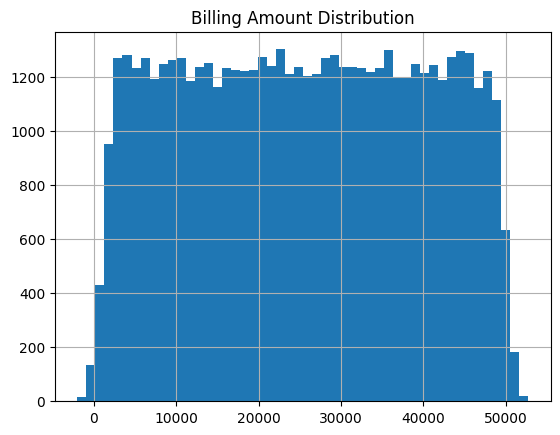

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64
Outlier range: -23628 to 74689
Outliers found: 0


In [20]:
# Visualise Billing Amount distribution
import matplotlib.pyplot as plt

df['Billing Amount'].hist(bins=50)
plt.title('Billing Amount Distribution')
plt.show()

# Check with stats
print(df['Billing Amount'].describe())

# Find outliers using IQR method
Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Outlier range: {lower:.0f} to {upper:.0f}")
print(f"Outliers found: {((df['Billing Amount'] < lower) | (df['Billing Amount'] > upper)).sum()}")

For healthcare billing, very high amounts can be real (ICU, surgery) so don't blindly drop them — just flag them:

In [21]:
df['Is_Billing_Outlier'] = (
    (df['Billing Amount'] < lower) | (df['Billing Amount'] > upper)
)

Create Derived Columns (Your Domain Value)
This is where you add business value — things the raw data doesn't have:

In [23]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'length of stay', 'Is_Billing_Outlier',
       'Age Group'],
      dtype='object')

In [26]:
# Age groups — useful for healthcare analysis
df['Age Group'] = pd.cut(df['Age'],
                         bins=[0, 18, 35, 60, 100],
                         labels=['Minor', 'Young Adult', 'Adult', 'Senior'])

# Length of stay already created in Step 3
# Now categorise it
df['Stay Category'] = pd.cut(df['length of stay'],
                              bins=[0, 3, 7, 14, 999],
                              labels=['Short', 'Medium', 'Long', 'Extended'])

# Billing per day — powerful metric
df['Billing Per Day'] = df['Billing Amount'] / df['length of stay']

 Final Validation & Save (Universal)

In [27]:
# Run these checks before saving — every time
print("Shape after cleaning:", df.shape)
print("Nulls remaining:\n", df.isnull().sum())
print("Duplicates remaining:", df.duplicated().sum())
print(df.dtypes)

# Save both versions
df.to_csv('healthcare_cleaned.csv', index=False)
print("Saved successfully!")

Shape after cleaning: (55500, 20)
Nulls remaining:
 Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
length of stay        0
Is_Billing_Outlier    0
Age Group             0
Stay Category         0
Billing Per Day       0
dtype: int64
Duplicates remaining: 534
Name                          object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type        

Your GitHub Commit Message for Today
Day 4: Pandas Advanced - Healthcare data cleaning
- Fixed date types, created Length of Stay column
- Standardised 6 categorical columns
- Handled Billing Amount outliers
- Created Age Group, Stay Category, Billing Per Day features